#  DocForge Exploratory Data Analysis

**Your job:** Fill in every `# TODO` cell below. Each cell tells you exactly what to do.

Do NOT skip cells — each one builds on the last.

---
### What is the dataset?
You are working with **Code2Doc** — a curated dataset of real function-documentation pairs scraped from popular open-source repositories (Spring, Pandas, TypeScript compiler, etc.).

Each row is one function paired with its docstring. Your goal in this notebook is to **understand the data** before you clean or train anything.

---
### Sections
1. Install & Import
2. Load the Dataset
3. Basic Overview
4. Language Distribution
5. Quality Score Analysis
6. Code Length Analysis
7. Docstring Length Analysis
8. Token Count Estimation
9. Cyclomatic Complexity
10. Per-Language Summary
11. Sample Inspection
12. Key Insights

---
## Section 1 — Install & Import

Run this cell as-is. It installs and imports everything you need.

In [2]:
!pip install datasets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11


---
## Section 2 — Load the Dataset

**Task:** Load the Code2Doc dataset from HuggingFace and convert the training split to a pandas DataFrame.

The dataset is hosted at: `kaanrkaraman/code2doc`

**Hint:** Use `load_dataset(...)` then `.to_pandas()` on the split you want..

In [3]:
# TODO: Load the dataset from HuggingFace
from datasets import load_dataset
dataset = load_dataset("kaanrkaraman/code2doc")

# TODO: Print the dataset object to see what splits exist
print(dataset)

# TODO: Convert the 'train' split to a pandas DataFrame called df
df = dataset["train"].to_pandas()

# TODO: Print how many rows and columns df has
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.shape)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/6.51M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/860k [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/857k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10684 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1340 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1334 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 10684
    })
    test: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 1340
    })
    val: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 1334
    })
})
Rows: 10684, Columns: 15
(10684, 15)


---
## Section 2b — Fix Array-Type Columns

Some columns (like `parameters`) store Python lists instead of plain strings.
This breaks `.unique()` and `.value_counts()` later on.

**Task:** Write a loop that checks each column, detects if its values are lists/arrays, and converts them to comma-separated strings.

**Hint:** Use `isinstance(value, (list, np.ndarray))` to check. Use `', '.join(...)` to convert.

In [4]:
# TODO: Loop through all columns in df
# For each column, check if the first non-null value is a list or np.ndarray
# If it is, convert the whole column by joining list items into a string
# Print which columns you are converting
for col in df.columns:
    first_val = df[col].dropna().iloc[0]
    
    if isinstance(first_val, (list, np.ndarray)):
        print(f"Converting column: {col}")
        df[col] = df[col].apply(lambda x: ', '.join(str(i) for i in x) if isinstance(x, (list, np.ndarray)) else x)

# TODO: After fixing, print df.dtypes to confirm everything is a scalar type
print(df.dtypes)


Converting column: parameters
function_name       object
function_code       object
documentation       object
language            object
file_path           object
line_number          int32
parameters          object
return_type         object
has_type_hints        bool
complexity           int32
quality_score      float32
repo_name           object
repo_stars           int32
docstring_style     object
is_async              bool
dtype: object


---
## Section 3 — Basic Overview

**Task:** Explore the structure of the DataFrame — what columns exist, what types they are, and whether any have missing values.

**Hint:** Use `.head()`, `.dtypes`, `.isnull().sum()`, and `.nunique()`.

In [5]:
# TODO: Show the first 3 rows of df
df.head(3)

# TODO: Print total number of rows and columns
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# TODO: Build a summary table showing: column name, dtype, null count, null %, unique value count
# Display it as a DataFrame
summary = pd.DataFrame({'dtype': df.dtypes,
    'null_count':   df.isnull().sum(),
    'null_%':       (df.isnull().sum() / len(df) * 100).round(2),
    'unique_count': df.nunique()
})
print(summary)

# TODO: Print each column name and the value of the very first row for that column
# (truncate long strings to 120 characters so the output stays readable)
for col in df.columns:
    value = str(df[col].iloc[0])[:120]
    print(f"\n{col}:\n{value}")


Rows: 10684, Columns: 15
                   dtype  null_count  null_%  unique_count
function_name     object           0     0.0          7511
function_code     object           0     0.0         10684
documentation     object           0     0.0          8616
language          object           0     0.0             5
file_path         object           0     0.0          2599
line_number        int32           0     0.0          2689
parameters        object           0     0.0          4572
return_type       object           0     0.0          1197
has_type_hints      bool           0     0.0             2
complexity         int32           0     0.0            32
quality_score    float32           0     0.0            45
repo_name         object           0     0.0            34
repo_stars         int32           0     0.0            34
docstring_style   object           0     0.0             7
is_async            bool           0     0.0             2

function_name:
parseTypeParame

---
## Section 4 — Language Distribution

**Task:** Find out how many samples exist per programming language, then visualize it.

**Hint:** The language column is called `language`. Use `.value_counts()` for counts.
Make a bar chart AND a pie chart side by side.

java: 6560 (61.4%)
python: 2885 (27.0%)
typescript: 681 (6.4%)
javascript: 428 (4.0%)
cpp: 130 (1.2%)


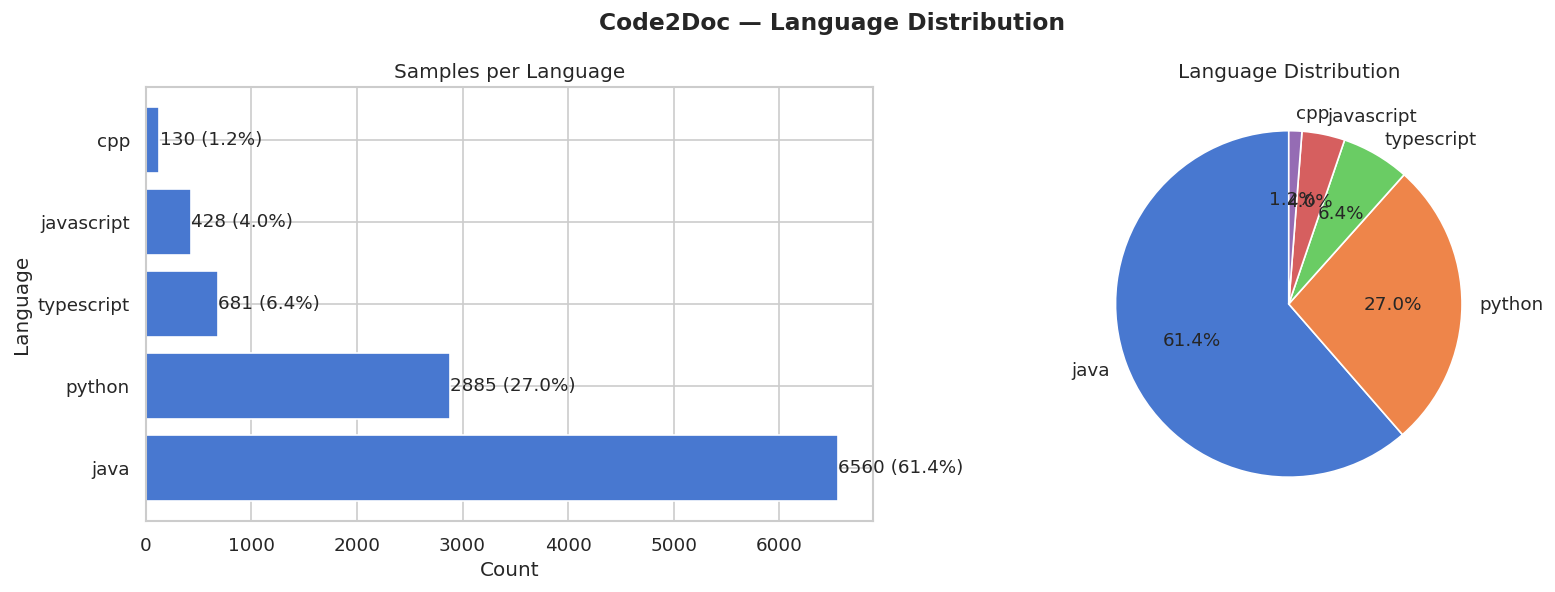

In [6]:
# TODO: Count samples per language and store in a variable
lang_counts = df['language'].value_counts()

# TODO: Print each language, its count, and its percentage of total
total=len(df)

for lang,count in lang_counts.items():
    print(f"{lang}: {count} ({count/total*100:.1f}%)")

# TODO: Create a figure with 1 row and 2 columns of subplots (figsize 14x5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot  → horizontal bar chart (languages on y-axis, counts on x-axis)
bars = ax1.barh(lang_counts.index, lang_counts.values)
ax1.set_xlabel('Count')
ax1.set_ylabel('Language')
ax1.set_title('Samples per Language')
#                 annotate each bar with its count and percentage
for bar, count in zip(bars, lang_counts.values):
    pct = count / total * 100
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{count} ({pct:.1f}%)', va='center')
# Right subplot → pie chart with language labels and percentages
ax2.pie(lang_counts.values, labels=lang_counts.index,
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Language Distribution')

# Add a title to the whole figure
fig.suptitle('Code2Doc — Language Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()

# TODO: Save the figure as 'eda_language_distribution.png'
plt.savefig('eda_language_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: Write 1 sentence observation about what you notice in the distribution
#Java and Python seem to dominate the dataset, indicating a class imbalance that may bias a model towards predicting the majority language(s)

---
## Section 5 — Quality Score Analysis

**Task:** Analyze the `quality_score` column — its distribution, key stats, and breakdown by language.

The quality score ranges from 0–10. All samples in this dataset should be ≥ 6.0.

**Hint:** Use `.describe()` for stats. Use `sns.boxplot` for the per-language breakdown.

Mean:   6.92
Median: 6.80
Std:    0.69
Min:    6.00
Max:    9.68
Q1:     6.40
Q3:     7.44


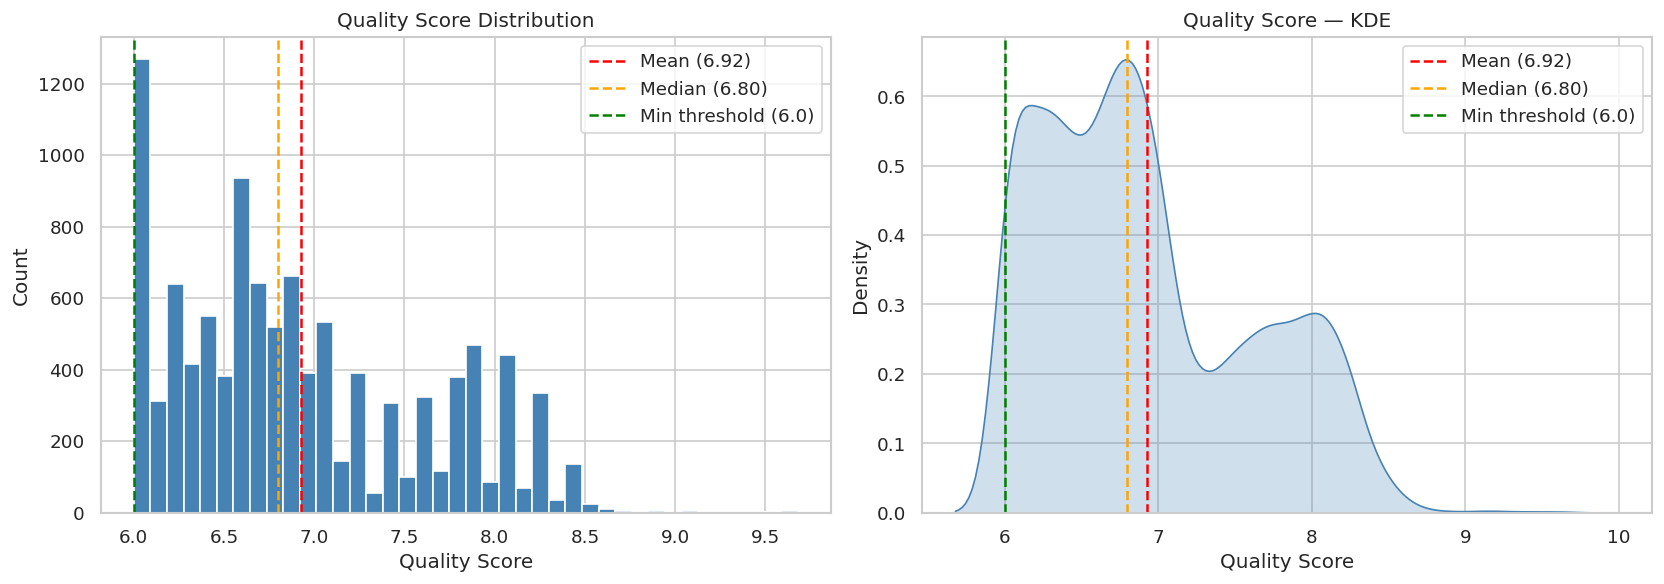

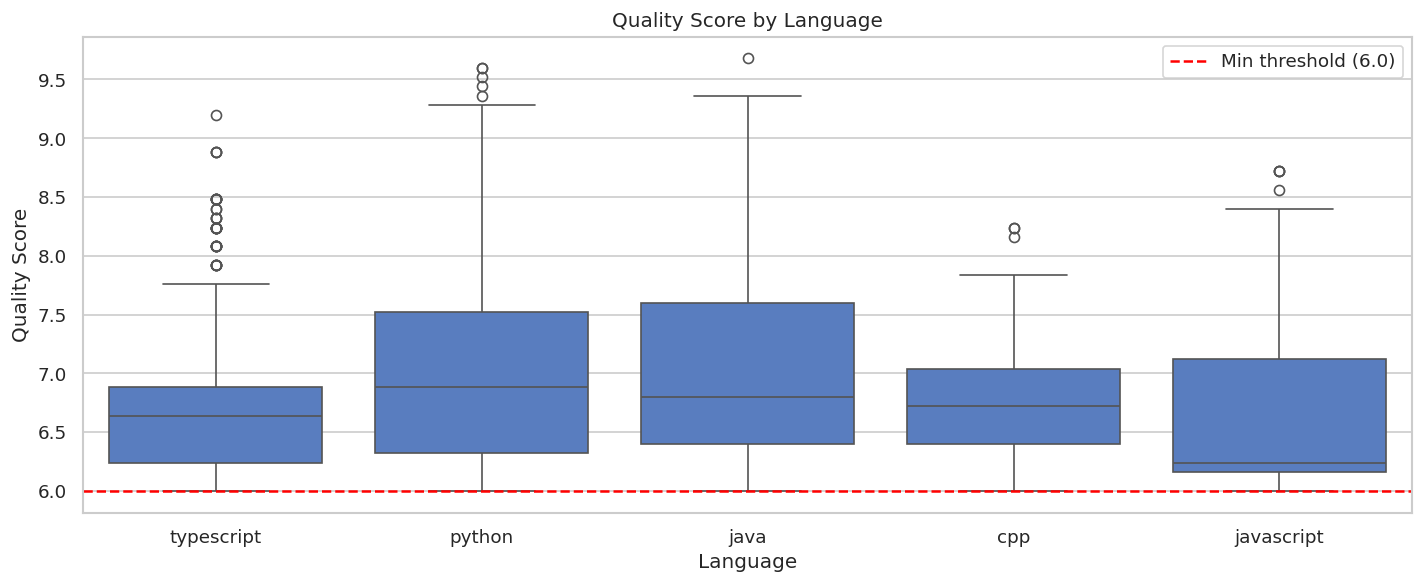

In [7]:
# TODO: Print mean, median, std, min, max, Q1, Q3 of quality_score
stats = df['quality_score'].describe()
print(f"Mean:   {df['quality_score'].mean():.2f}")
print(f"Median: {df['quality_score'].median():.2f}")
print(f"Std:    {df['quality_score'].std():.2f}")
print(f"Min:    {df['quality_score'].min():.2f}")
print(f"Max:    {df['quality_score'].max():.2f}")
print(f"Q1:     {stats['25%']:.2f}")
print(f"Q3:     {stats['75%']:.2f}")

# TODO: Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

mean_val   = df['quality_score'].mean()
median_val = df['quality_score'].median()

# Left  → histogram of quality_score (40 bins)
ax1.hist(df['quality_score'], bins=40, color='steelblue', edgecolor='white')
#          add vertical lines for mean, median, and the minimum threshold (6.0)
ax1.axvline(mean_val,   color='red',    linestyle='--', label=f'Mean ({mean_val:.2f})')
ax1.axvline(median_val, color='orange', linestyle='--', label=f'Median ({median_val:.2f})')
ax1.axvline(6.0,        color='green',  linestyle='--', label='Min threshold (6.0)')
ax1.set_title('Quality Score Distribution')
ax1.set_xlabel('Quality Score')
ax1.set_ylabel('Count')

#          add a legend
ax1.legend()

# Right → KDE (kernel density) plot of quality_score
sns.kdeplot(df['quality_score'], ax=ax2, fill=True, color='steelblue')
ax2.axvline(mean_val,   color='red',    linestyle='--', label=f'Mean ({mean_val:.2f})')
ax2.axvline(median_val, color='orange', linestyle='--', label=f'Median ({median_val:.2f})')
ax2.axvline(6.0,        color='green',  linestyle='--', label='Min threshold (6.0)')
ax2.set_title('Quality Score — KDE')
ax2.set_xlabel('Quality Score')
ax2.legend()

plt.tight_layout()
plt.savefig('eda_quality_score_dist.png', dpi=120, bbox_inches='tight')
plt.show()


# TODO: Create a separate boxplot showing quality_score grouped by language
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='language', y='quality_score', ax=ax)

# Add a horizontal dashed line at y=6.0 to show the minimum threshold
ax.axhline(6.0, color='red', linestyle='--', label='Min threshold (6.0)')
ax.set_title('Quality Score by Language')
ax.set_xlabel('Language')
ax.set_ylabel('Quality Score')
ax.legend()
plt.tight_layout()
plt.savefig('eda_quality_score_by_language.png', dpi=120, bbox_inches='tight')
plt.show()



# TODO: Write 1 sentence about what the quality distribution tells you
#Most samples cluster above the 6.0 threshold as expected, but the spread and outliers vary by language, suggesting some languages have more consistently high-quality documentation than others.

---
## Section 6 — Code Length Analysis

**Task:** Measure how long the functions are — in characters and in lines.

**Hint:** Use `.str.len()` for character count. Use `.str.count('\\n') + 1` for line count.
Cap your histograms at the 99th percentile so outliers don't squash the chart.

=== code_char_len ===
count    10684.000000
mean       771.504586
std        825.278555
min         20.000000
25%        197.000000
50%        445.000000
75%       1069.000000
max       4990.000000
Name: code_char_len, dtype: float64

=== code_line_count ===
count    10684.000000
mean        20.584051
std         21.907444
min          1.000000
25%          5.000000
50%         12.000000
75%         29.000000
max        164.000000
Name: code_line_count, dtype: float64


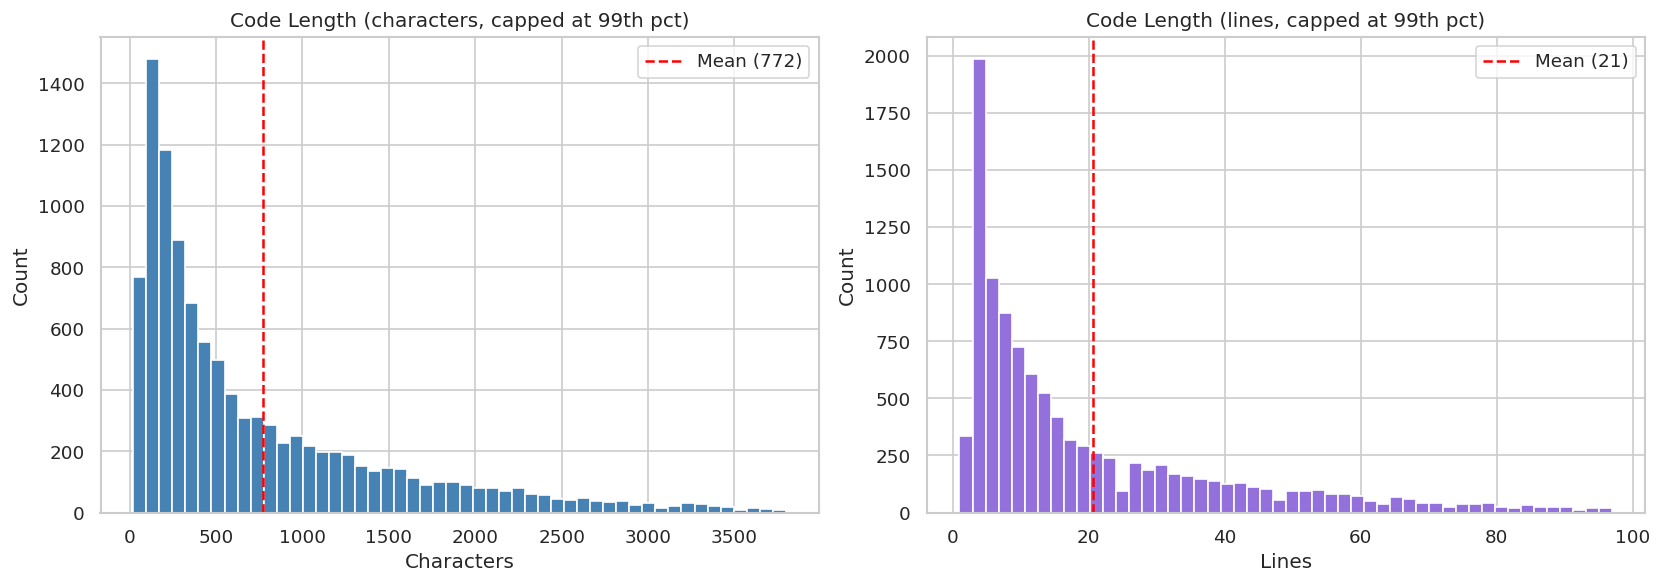

In [8]:
# TODO: Create two new columns:
#   'code_char_len'  → number of characters in the function_code column
#   'code_line_count' → number of lines in the function_code column
df['code_char_len']   = df['function_code'].str.len()
df['code_line_count'] = df['function_code'].str.count('\n') + 1


# TODO: Print descriptive stats for both new columns
print("=== code_char_len ===")
print(df['code_char_len'].describe())
print("\n=== code_line_count ===")
print(df['code_line_count'].describe())

# TODO: Plot 2 histograms side by side (50 bins each)
# Left  → code_char_len  (capped at 99th percentile)
# Right → code_line_count (capped at 99th percentile)
# Add a red dashed vertical line for the mean on each
char_cap = df['code_char_len'].quantile(0.99)
line_cap = df['code_line_count'].quantile(0.99)

char_data = df[df['code_char_len']   <= char_cap]['code_char_len']
line_data = df[df['code_line_count'] <= line_cap]['code_line_count']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(char_data, bins=50, color='steelblue', edgecolor='white')
ax1.axvline(df['code_char_len'].mean(), color='red', linestyle='--',label=f"Mean ({df['code_char_len'].mean():.0f})")
ax1.set_title('Code Length (characters, capped at 99th pct)')
ax1.set_xlabel('Characters')
ax1.set_ylabel('Count')
ax1.legend()

ax2.hist(line_data, bins=50, color='mediumpurple', edgecolor='white')
ax2.axvline(df['code_line_count'].mean(), color='red', linestyle='--',label=f"Mean ({df['code_line_count'].mean():.0f})")
ax2.set_title('Code Length (lines, capped at 99th pct)')
ax2.set_xlabel('Lines')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.savefig('eda_code_length.png', dpi=120, bbox_inches='tight')
plt.show()


# TODO: Write 1 sentence about what the typical function length looks like
#Most functions are relatively short, with the typical function being around the mean line, while a small number of very long functions pull the tail out.


---
## Section 7 — Docstring Length Analysis

**Task:** Measure how long the docstrings are, then compute the ratio of docstring length to code length.

A ratio > 1 means the docstring is longer than the code — which is actually fine for training.

=== doc_char_len ===
count    10684.000000
mean       410.318701
std        364.138920
min         50.000000
25%        167.000000
50%        285.000000
75%        516.000000
max       1998.000000
Name: doc_char_len, dtype: float64

=== doc_word_count ===
count    10684.000000
mean        59.841164
std         51.396198
min          3.000000
25%         26.000000
50%         43.000000
75%         76.000000
max        325.000000
Name: doc_word_count, dtype: float64


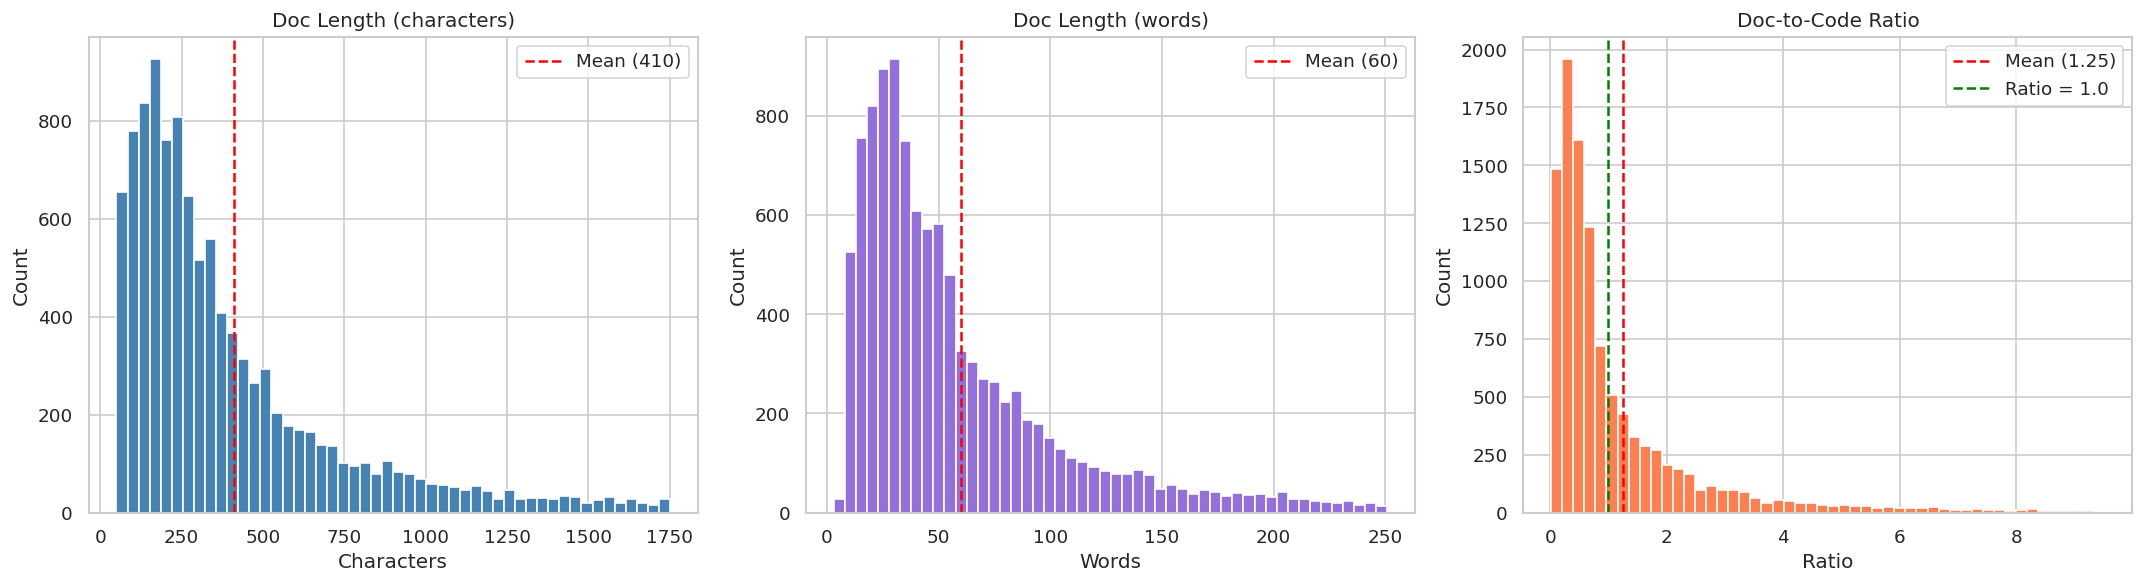

In [9]:
# TODO: Create two new columns:
#   'doc_char_len'  → number of characters in the documentation column
#   'doc_word_count' → number of words in the documentation column
df['doc_char_len']  = df['documentation'].str.len()
df['doc_word_count'] = df['documentation'].str.split().str.len()



# TODO: Print descriptive stats for both new columns
print("=== doc_char_len ===")
print(df['doc_char_len'].describe())
print("\n=== doc_word_count ===")
print(df['doc_word_count'].describe())


# TODO: Create a third column:
#   'doc_to_code_ratio' → doc_char_len divided by code_char_len
#   Be careful of division by zero — replace 0 in the denominator with NaN
df['doc_to_code_ratio'] = df['doc_char_len'] / df['code_char_len'].replace(0, float('nan'))



# TODO: Plot 3 histograms (you can do 1 row x 3 cols, or 2 rows)
# 1. doc_char_len histogram (capped at 99th pct)
# 2. doc_word_count histogram (capped at 99th pct)
# 3. doc_to_code_ratio histogram (capped at 99th pct)
char_cap  = df['doc_char_len'].quantile(0.99)
word_cap  = df['doc_word_count'].quantile(0.99)
ratio_cap = df['doc_to_code_ratio'].quantile(0.99)

char_data  = df[df['doc_char_len']     <= char_cap]['doc_char_len']
word_data  = df[df['doc_word_count']   <= word_cap]['doc_word_count']
ratio_data = df[df['doc_to_code_ratio'] <= ratio_cap]['doc_to_code_ratio']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.hist(char_data, bins=50, color='steelblue', edgecolor='white')
ax1.axvline(df['doc_char_len'].mean(), color='red', linestyle='--',
            label=f"Mean ({df['doc_char_len'].mean():.0f})")
ax1.set_title('Doc Length (characters)')
ax1.set_xlabel('Characters')
ax1.set_ylabel('Count')
ax1.legend()

ax2.hist(word_data, bins=50, color='mediumpurple', edgecolor='white')
ax2.axvline(df['doc_word_count'].mean(), color='red', linestyle='--',
            label=f"Mean ({df['doc_word_count'].mean():.0f})")
ax2.set_title('Doc Length (words)')
ax2.set_xlabel('Words')
ax2.set_ylabel('Count')
ax2.legend()

ax3.hist(ratio_data, bins=50, color='coral', edgecolor='white')
ax3.axvline(df['doc_to_code_ratio'].mean(), color='red', linestyle='--',
            label=f"Mean ({df['doc_to_code_ratio'].mean():.2f})")
ax3.axvline(1.0, color='green', linestyle='--', label='Ratio = 1.0')
ax3.set_title('Doc-to-Code Ratio')
ax3.set_xlabel('Ratio')
ax3.set_ylabel('Count')
ax3.legend()

plt.tight_layout()
plt.savefig('eda_doc_length.png', dpi=120, bbox_inches='tight')
plt.show()



# TODO: Write 1 sentence about the doc-to-code ratio distribution
#The doc-to-code ratio is right-skewed with many samples near or above 1.0, meaning docstrings are often as long as or longer than the code

---
## Section 8 — Token Count Estimation

**Task:** Estimate how many tokens each function and docstring will take up when fed to a model.

We can't load the tokenizer here due to a version conflict, so use this approximation:
> **tokens ≈ characters ÷ 4** (standard heuristic, accurate within ~10% for CodeT5)

Your goal is to find what `max_length` value covers at least 90% of samples.

=== code_tokens ===
count    2000.00000
mean      187.75550
std       203.50293
min         5.00000
25%        47.00000
50%       105.00000
75%       267.25000
max      1226.00000
Name: code_tokens, dtype: float64

=== doc_tokens ===
count    2000.00000
mean       99.34800
std        91.09036
min        12.00000
25%        41.00000
50%        68.00000
75%       121.00000
max       491.00000
Name: doc_tokens, dtype: float64


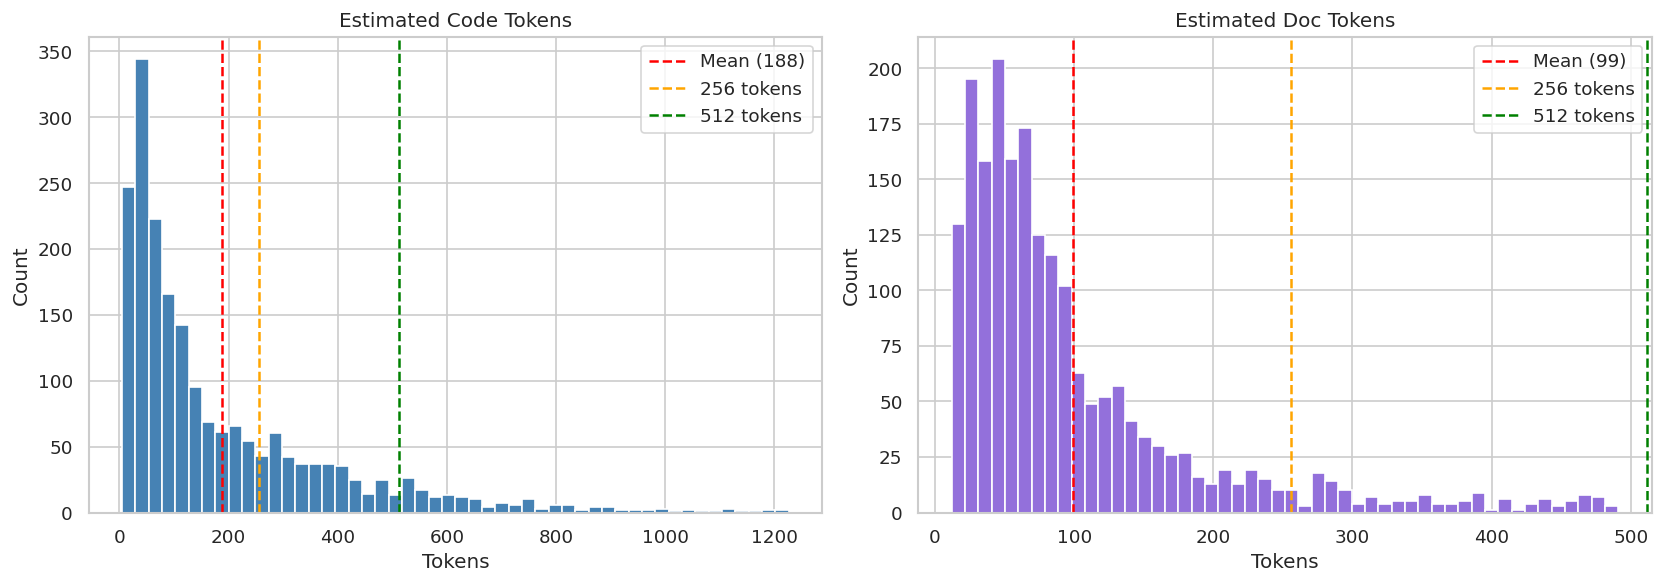

=== Code Token Coverage ===
  <  128 tokens: 56.1% of samples
  <  256 tokens: 73.9% of samples
  <  512 tokens: 91.6% of samples
  < 1024 tokens: 99.4% of samples

=== Doc Token Coverage ===
  <   64 tokens: 46.0% of samples
  <  128 tokens: 76.4% of samples
  <  256 tokens: 92.4% of samples
  <  512 tokens: 100.0% of samples
Recommended max_input_length  = 512
Recommended max_target_length = 256


In [11]:
# TODO: Sample 2000 rows randomly from df (use random_state=42 for reproducibility)
sample=df.sample(2000,random_state=42).copy()

# TODO: Add two columns to your sample:
#   'code_tokens' → estimated token count for function_code (chars // 4)
#   'doc_tokens'  → estimated token count for documentation  (chars // 4)
sample['code_tokens'] = sample['code_char_len'] // 4
sample['doc_tokens']  = sample['doc_char_len']  // 4



# TODO: Print descriptive stats for code_tokens and doc_tokens
print("=== code_tokens ===")
print(sample['code_tokens'].describe())
print("\n=== doc_tokens ===")
print(sample['doc_tokens'].describe())



# TODO: Plot 2 histograms side by side
# Add vertical lines at 256 and 512 tokens on each
# Add a red line for the mean
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(sample['code_tokens'], bins=50, color='steelblue', edgecolor='white')
ax1.axvline(sample['code_tokens'].mean(), color='red',    linestyle='--', label=f"Mean ({sample['code_tokens'].mean():.0f})")
ax1.axvline(256,  color='orange', linestyle='--', label='256 tokens')
ax1.axvline(512,  color='green',  linestyle='--', label='512 tokens')
ax1.set_title('Estimated Code Tokens')
ax1.set_xlabel('Tokens')
ax1.set_ylabel('Count')
ax1.legend()

ax2.hist(sample['doc_tokens'], bins=50, color='mediumpurple', edgecolor='white')
ax2.axvline(sample['doc_tokens'].mean(), color='red',    linestyle='--', label=f"Mean ({sample['doc_tokens'].mean():.0f})")
ax2.axvline(256,  color='orange', linestyle='--', label='256 tokens')
ax2.axvline(512,  color='green',  linestyle='--', label='512 tokens')
ax2.set_title('Estimated Doc Tokens')
ax2.set_xlabel('Tokens')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.savefig('eda_token_counts.png', dpi=120, bbox_inches='tight')
plt.show()


# TODO: Print a coverage table — for each limit below,
# what % of samples have FEWER tokens than the limit?
# Code limits to check : 128, 256, 512, 1024
# Doc limits to check  : 64, 128, 256, 512
print("=== Code Token Coverage ===")
for limit in [128, 256, 512, 1024]:
    pct = (sample['code_tokens'] < limit).mean() * 100
    print(f"  < {limit:>4} tokens: {pct:.1f}% of samples")

print("\n=== Doc Token Coverage ===")
for limit in [64, 128, 256, 512]:
    pct = (sample['doc_tokens'] < limit).mean() * 100
    print(f"  < {limit:>4} tokens: {pct:.1f}% of samples")


# TODO: Based on your coverage table, fill in these values:
print('Recommended max_input_length  = 512')
print('Recommended max_target_length = 256')


---
## Section 9 — Cyclomatic Complexity

**Task:** Analyze the `complexity` column — this measures how many branches (if/else/for/while) a function has.

Low complexity = simple function. High complexity = hard to document automatically.
The dataset intentionally filters out very trivial AND very complex functions.

Mean:   3.37
Median: 2.00
Std:    3.08
Min:    1.00
Max:    51.00


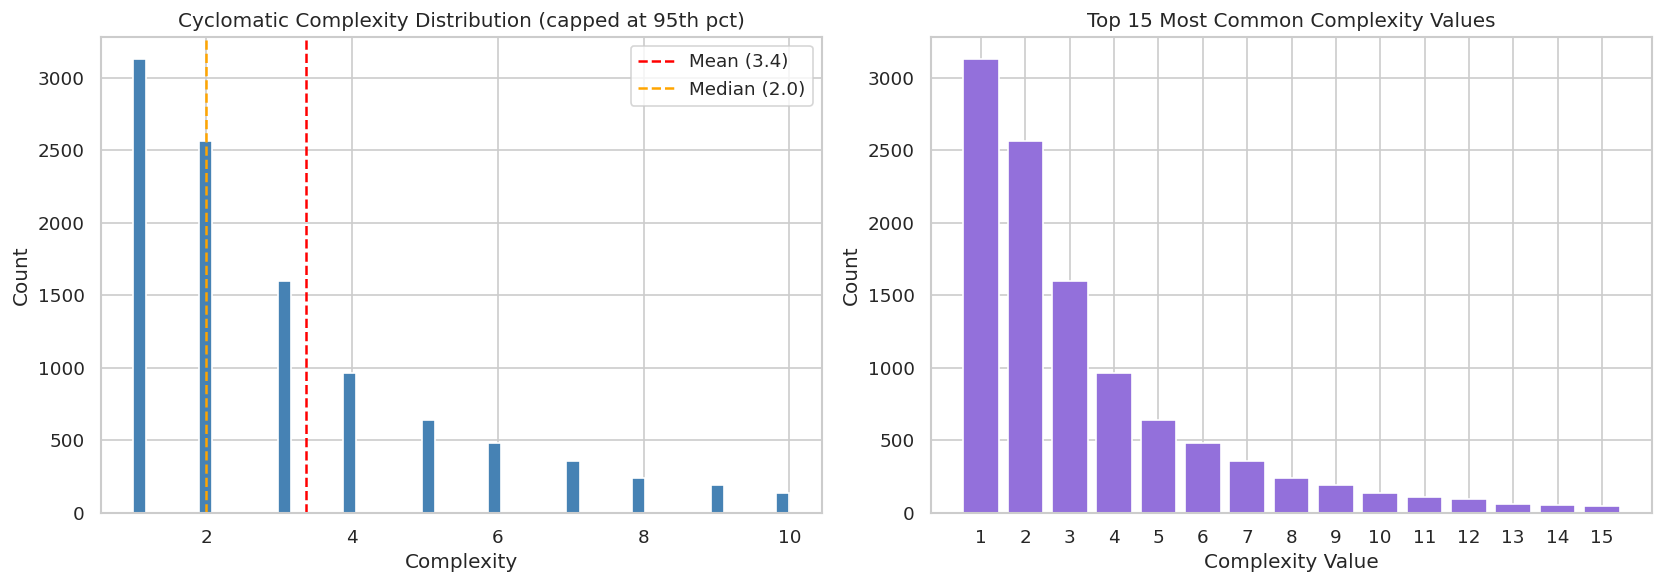

In [12]:
# TODO: Print mean, median, std, min, max for the 'complexity' column
print(f"Mean:   {df['complexity'].mean():.2f}")
print(f"Median: {df['complexity'].median():.2f}")
print(f"Std:    {df['complexity'].std():.2f}")
print(f"Min:    {df['complexity'].min():.2f}")
print(f"Max:    {df['complexity'].max():.2f}")


# TODO: Plot 2 charts side by side
# Left  → histogram of complexity (capped at 95th percentile)
#          add mean and median vertical lines
# Right → bar chart of the top 15 most common complexity values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cap = df['complexity'].quantile(0.95)
cap_data = df[df['complexity'] <= cap]['complexity']

ax1.hist(cap_data, bins=50, color='steelblue', edgecolor='white')
ax1.axvline(df['complexity'].mean(),   color='red',    linestyle='--',
            label=f"Mean ({df['complexity'].mean():.1f})")
ax1.axvline(df['complexity'].median(), color='orange', linestyle='--',
            label=f"Median ({df['complexity'].median():.1f})")
ax1.set_title('Cyclomatic Complexity Distribution (capped at 95th pct)')
ax1.set_xlabel('Complexity')
ax1.set_ylabel('Count')
ax1.legend()

top15 = df['complexity'].value_counts().head(15).sort_index()
ax2.bar(top15.index.astype(str), top15.values, color='mediumpurple', edgecolor='white')
ax2.set_title('Top 15 Most Common Complexity Values')
ax2.set_xlabel('Complexity Value')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_complexity.png', dpi=120, bbox_inches='tight')
plt.show()



# TODO: Write 1 sentence about what complexity range most functions fall in
#Most functions cluster at low-complexity values roughtly, from around 1-6


---
## Section 10 — Per-Language Summary

**Task:** Build a summary table that shows, for each language:
- number of samples
- average code length (chars)
- average code length (lines)
- average docstring length (chars)
- average word count
- average quality score
- average complexity

Then visualize it as a heatmap.

            num_samples  avg_code_chars  avg_code_lines  avg_doc_chars  \
language                                                                 
cpp                 130          594.32           17.17         141.98   
java               6560          446.38           11.05         347.91   
javascript          428          505.48           16.53         338.39   
python             2885         1530.99           43.25         607.84   
typescript          681          886.93           19.64         271.15   

            avg_word_count  avg_quality  avg_complexity  
language                                                 
cpp                  22.65         6.72            3.76  
java                 50.96         6.96            2.70  
javascript           50.55         6.62            4.04  
python               87.34         6.96            4.50  
typescript           41.84         6.64            4.56  


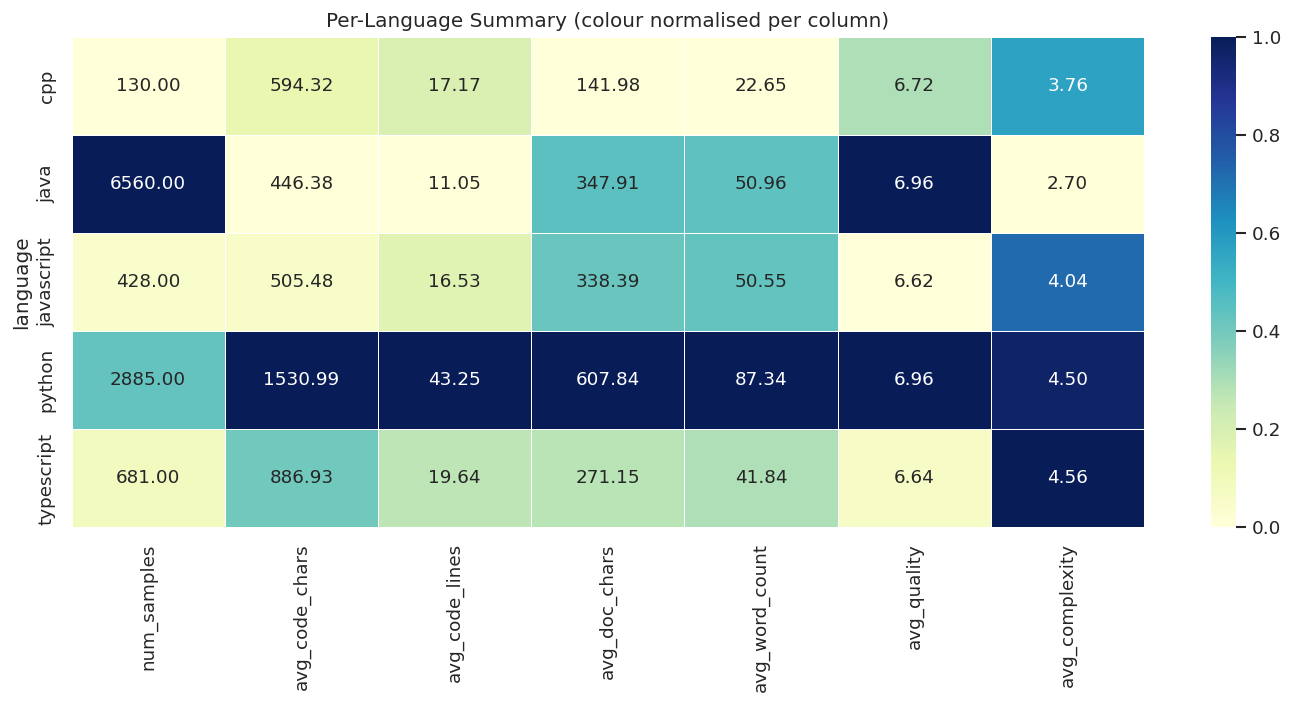

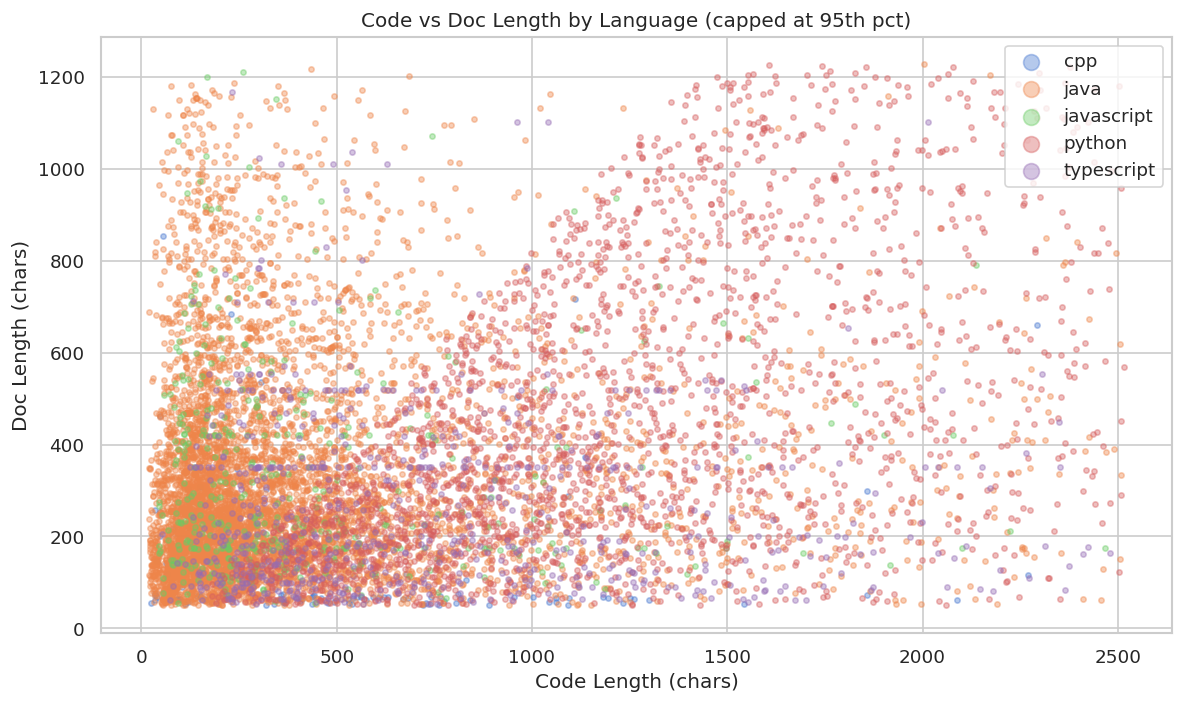

In [13]:
# TODO: Use groupby('language') to compute the summary table described above
# Round all values to 2 decimal places
# Print the full table
summary = df.groupby('language').agg(
    num_samples    = ('function_code',  'count'),
    avg_code_chars = ('code_char_len',  'mean'),
    avg_code_lines = ('code_line_count','mean'),
    avg_doc_chars  = ('doc_char_len',   'mean'),
    avg_word_count = ('doc_word_count', 'mean'),
    avg_quality    = ('quality_score',  'mean'),
    avg_complexity = ('complexity',     'mean')
).round(2)
print(summary)

# TODO: Create a heatmap of this summary table
# Normalize the color scale per column (so different units don't distort colors)
# Annotate cells with actual values
# Use a YlGnBu colormap

summary_norm=(summary-summary.min())/(summary.max()-summary.min())
plt.figure(figsize=(12, 6))
sns.heatmap(
    summary_norm,
    annot=summary.values,      
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5,
    yticklabels=summary.index)
plt.title('Per-Language Summary (colour normalised per column)')
plt.tight_layout()
plt.savefig('eda_per_language_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


# TODO: Also create a scatter plot:
# x-axis = code_char_len, y-axis = doc_char_len
# Color each point by language
# Cap both axes at the 95th percentile to remove outliers

x_cap = df['code_char_len'].quantile(0.95)
y_cap = df['doc_char_len'].quantile(0.95)
scatter_df = df[(df['code_char_len'] <= x_cap) & (df['doc_char_len'] <= y_cap)]

plt.figure(figsize=(10, 6))
for lang, group in scatter_df.groupby('language'):
    plt.scatter(group['code_char_len'], group['doc_char_len'],
                label=lang, alpha=0.4, s=10)

plt.xlabel('Code Length (chars)')
plt.ylabel('Doc Length (chars)')
plt.title('Code vs Doc Length by Language (capped at 95th pct)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('eda_code_vs_doc_scatter.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 11 — Sample Inspection

**Task:** Look at actual examples from the dataset. Reading real samples is the best way to understand what the model will need to learn.

Print at least:
- 1 Python sample
- 1 Java sample
- The top 3 highest quality samples (any language)

In [18]:
# TODO: Write a helper function print_sample(row) that prints:
# - language
# - quality_score
# - function_code (first 500 chars)
# - documentation (first 400 chars)
# with clear separators between fields

def print_sample(row):
    print("="*60)
    print(f"Language      : {row['language']}")
    print(f"Quality Score : {row['quality_score']}")
    print("-" * 60)
    print("FUNCTION CODE (first 500 chars):")
    print(row['function_code'][:500])
    print("-" * 60)
    print("DOCUMENTATION (first 400 chars):")
    print(row['documentation'][:400])
    print("=" * 60)


# TODO: Print one Python sample using your function
python_sample = df[df['language'] == 'python'].iloc[0]
print_sample(python_sample)


# TODO: Print one Java sample
java_sample = df[df['language'] == 'java'].iloc[0]
print_sample(java_sample)


# TODO: Find the top 3 rows by quality_score and print each one
top3 = df.nlargest(3, 'quality_score')
for _, row in top3.iterrows():
    print_sample(row)


Language      : python
Quality Score : 6.960000038146973
------------------------------------------------------------
FUNCTION CODE (first 500 chars):
def convert(self, values: np.ndarray, nan_rep, encoding: str, errors: str):
        """
        Convert the data from this selection to the appropriate pandas type.

        Parameters
        ----------
        values : np.ndarray
        nan_rep :
        encoding : str
        errors : str

        Returns
        -------
        index : listlike to become an Index
        data : ndarraylike to become a column
        """
        assert isinstance(values, np.ndarray), type(values)

        # 
------------------------------------------------------------
DOCUMENTATION (first 400 chars):
Convert the data from this selection to the appropriate pandas type.

Parameters
----------
values : np.ndarray
nan_rep :
encoding : str
errors : str

Returns
-------
index : listlike to become an Index
data : ndarraylike to become a column
Language     

---
## Section 12 — Key Insights Summary

**Task:** Fill in the summary below based on what you found in the analysis above.
This is the most important cell — it forces you to actually interpret the numbers.

Replace every `???` with the real value from your EDA.

In [19]:
# TODO: Replace every ??? below with the actual value from your analysis

total_samples    = len(df)
num_languages    = df['language'].nunique()
dominant_lang    = df['language'].value_counts().index[0]
dominant_pct     = df['language'].value_counts().iloc[0] / total_samples * 100

quality_mean     = df['quality_score'].mean()
quality_std      = df['quality_score'].std()
all_above_6      = "Yes" if df['quality_score'].min() >= 6.0 else "No"

avg_code_chars   = df['code_char_len'].mean()
avg_code_lines   = df['code_line_count'].mean()

avg_doc_chars    = df['doc_char_len'].mean()
avg_doc_words    = df['doc_word_count'].mean()

mean_cc          = df['complexity'].mean()
median_cc        = df['complexity'].median()

pct_code_512     = (df['code_char_len'] / 4 < 512).mean() * 100
pct_doc_256      = (df['doc_char_len']  / 4 < 256).mean() * 100

# max_input/target_length — fill from your Section 8 coverage table output
max_input_length  = 512   # replace with your value
max_target_length = 256   # replace with your value

# Now print the summary
print('=' * 60)
print('       DOCFORGE EDA — KEY INSIGHTS')
print('=' * 60)
print(f"""
Dataset
  Total samples        : {total_samples}
  Number of languages  : {num_languages}
  Dominant language    : {dominant_lang} ({dominant_pct:.1f}%)

Quality Scores
  Mean                 : {quality_mean:.2f}
  Std deviation        : {quality_std:.2f}
  All samples above 6.0: {all_above_6}

Code Length
  Average chars        : {avg_code_chars:.2f}
  Average lines        : {avg_code_lines:.2f}

Docstring Length
  Average chars        : {avg_doc_chars:.2f}
  Average words        : {avg_doc_words:.2f}

Complexity
  Mean cyclomatic CC   : {mean_cc:.2f}
  Median cyclomatic CC : {median_cc:.2f}

Token Estimates (chars / 4)
  % code fits in 512   : {pct_code_512:.1f}%
  % doc fits in 256    : {pct_doc_256:.1f}%

Recommended Settings for Notebook 2
  max_input_length     : {max_input_length}
  max_target_length    : {max_target_length}
""")
print('=' * 60)

       DOCFORGE EDA — KEY INSIGHTS

Dataset
  Total samples        : 10684
  Number of languages  : 5
  Dominant language    : java (61.4%)

Quality Scores
  Mean                 : 6.92
  Std deviation        : 0.69
  All samples above 6.0: Yes

Code Length
  Average chars        : 771.50
  Average lines        : 20.58

Docstring Length
  Average chars        : 410.32
  Average words        : 59.84

Complexity
  Mean cyclomatic CC   : 3.37
  Median cyclomatic CC : 2.00

Token Estimates (chars / 4)
  % code fits in 512   : 91.2%
  % doc fits in 256    : 92.3%

Recommended Settings for Notebook 2
  max_input_length     : 512
  max_target_length    : 256



---
##  Done!

Before moving to preprocessing, make sure you can answer these questions:

1. What are the 5 programming languages in the dataset and their proportions?
2. Why does Java dominate — what does that tell us about documentation culture?
3. What is the quality score range and what does the minimum threshold of 6.0 mean?
4. What `max_input_length` and `max_target_length` will you use for CodeT5 and why?
5. What is cyclomatic complexity and why does the dataset filter out very high values?
6. What does a doc-to-code ratio > 1 mean — is it a problem?

Write your answers in the cell below as comments.

In [ ]:
# Q1: Languages and proportions
# Answer: The dataset contains java(61.4%),python(27.0%),typescript(6.4%),javascript(4.0%),cpp(1.2%)


# Q2: Why does Java dominate?
# Answer: Java developers are traditionally required to write documentation
#(Javadoc) as part of standard practice. This means there is a lot more
# high-quality, consistently written documentation available to scrape
# compared to languages like Python or JavaScript where it is optional.

# Q3: Quality score range and what 6.0 means
# Answer:Quality scores range from 0-10. The dataset filters to only include
# samples with score >= 6.0, meaning only medium-to-high quality docstrings are
# kept. This threshold removes auto-generated, trivial, or incomplete documentation
# so the model learns from genuinely useful examples.

# Q4: max_input_length and max_target_length choice
# Answer:We choose max_input_length = 512 and max_target_length = 256.
# These values balance coverage vs memory — longer max_length means fewer samples get truncated but uses more GPU memory during training.


# Q5: What is cyclomatic complexity?
# Answer: Cyclomatic complexity counts the number of independent paths through a function — every if/else/for/while adds 1. Low complexity means simple linear function,
# High complexity means many branching conditions. The dataset filters out very high complexity functions because they are too hard to document automatically, and
# very low complexity because they are too trivial to be useful training examples.


# Q6: doc-to-code ratio > 1
# Answer: A ratio > 1 means the docstring is longer in characters than the code itself. This is not a problem, as this means the code is well-described. 
